# Métricas de Riesgo — FALABELLA.SN

Cálculo de las tres métricas de riesgo fundamentales usadas en la industria financiera (AFPs, family offices, bancos de inversión) aplicadas a Falabella S.A.C.I. en el período Mayo 2024 – Mayo 2026.

| Métrica | Pregunta que responde |
|---|---|
| **VaR** | ¿Cuánto puedo perder en un día malo? |
| **CVaR** | ¿Cuánto pierdo en promedio cuando ese día malo ocurre? |
| **Maximum Drawdown** | ¿Cuánto puede caer el capital desde su peak antes de recuperarse? |

In [38]:
import pandas as pd
import yfinance as yf
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [39]:
lista_nombre_acciones = ["COPEC.SN", "FALABELLA.SN", "CMPC.SN", "CENCOSUD.SN","ENELCHILE.SN", "BSANTANDER.SN", "BCI.SN","CAP.SN", "AGUAS-A.SN"]
datos_brutos_acciones = yf.download(tickers = lista_nombre_acciones, period = "2y")
lista_nombre_acciones.append("ECH")
ech = yf.download("ECH", period="2y")["Close"]
precios_cierre = datos_brutos_acciones["Close"].copy()
precios_cierre["ECH"] = ech.reindex(precios_cierre.index).ffill().bfill()
precios_cierre

[*********************100%***********************]  9 of 9 completed
[*********************100%***********************]  1 of 1 completed


Ticker,AGUAS-A.SN,BCI.SN,BSANTANDER.SN,CAP.SN,CENCOSUD.SN,CMPC.SN,COPEC.SN,ENELCHILE.SN,FALABELLA.SN,ECH
Date,,,,,,,,,,
2024-05-22,249.061493,25499.734375,40.828449,6586.000000,1815.466553,1898.608521,7481.546875,48.518719,2669.521973,27.301796
2024-05-23,249.982880,25547.900391,41.009106,6542.000000,1844.986206,1938.860840,7530.638184,49.058754,2688.727051,27.510353
2024-05-24,251.798416,25518.623047,40.882645,6683.299805,1832.489624,1942.231812,7530.638184,49.549168,2627.750488,27.643070
2024-05-27,251.798416,25317.458984,40.918777,6735.000000,1837.409668,1951.154663,7669.076172,49.811859,2602.303711,27.643070
2024-05-28,248.149155,25367.511719,40.349705,6585.000000,1798.837036,1982.880737,7590.628418,49.268356,2628.230469,27.899023
...,...,...,...,...,...,...,...,...,...,...
2026-05-15,324.000000,59193.000000,68.989998,6607.500000,2060.000000,1055.000000,6145.000000,76.809998,5500.200195,39.240002
2026-05-18,329.989990,59600.000000,69.169998,6550.000000,2106.000000,1061.000000,6450.000000,76.800003,5650.000000,39.830002
2026-05-19,333.850006,58399.000000,68.250000,6531.299805,2071.500000,1065.000000,6400.000000,75.150002,5445.000000,39.380001


## 1. Value at Risk (VaR)

El **VaR al X%** es la pérdida máxima esperada en un día normal con probabilidad (1-X%). Por ejemplo, VaR 95% significa que solo el 5% de los días la pérdida supera ese umbral.

Se calcula como el percentil 5% (VaR 95%) y 1% (VaR 99%) de la distribución histórica de retornos diarios.

## 2. CVaR — Expected Shortfall

El **CVaR (Conditional Value at Risk)** o Expected Shortfall responde: cuando el VaR se supera, ¿cuánto se pierde en promedio?

Se calcula filtrando solo los retornos peores que el umbral VaR y tomando su promedio. Siempre es más negativo que el VaR correspondiente.

In [40]:
retorno = precios_cierre.pct_change()

retornos_95 = retorno[retorno <  retorno.quantile(0.05)] * 100
retornos_99 = retorno[retorno <  retorno.quantile(0.01)] * 100

media = retorno.mean()
dst = retorno.std()
parametrico_95 = (-1.645*dst + media)*100
parametrico_99 = (-2.326*dst + media)*100

mc_95 = {}
mc_99 = {}

np.random.seed(42)
for i in retorno.columns:
    mc = np.random.normal(media[i], dst[i], 10000)
    mc.sort()
    mc_95[i] = np.quantile(mc, 0.05)*100
    mc_99[i] = np.quantile(mc, 0.01)*100
    

pd.DataFrame({"VaR 95 [%]": retorno.quantile(0.05) * 100, 
              "VaR Paramétrico 95 [%]" : parametrico_95,
              "MC 95 [%]" : mc_95,
              "VaR 99 [%]": retorno.quantile(0.01) * 100,
              "VaR Paramétrico 99 [%]": parametrico_99,
              "MC 99 [%]": mc_99})

,VaR 95 [%],VaR Paramétrico 95 [%],MC 95 [%],VaR 99 [%],VaR Paramétrico 99 [%],MC 99 [%]
AGUAS-A.SN,-1.884379,-1.953969,-1.966083,-3.262092,-2.790764,-2.784058
BCI.SN,-2.268527,-2.430975,-2.374252,-3.643769,-3.513733,-3.595797
BSANTANDER.SN,-1.896086,-1.952971,-1.917702,-2.881721,-2.809940,-2.780028
CAP.SN,-2.646868,-2.717012,-2.726286,-3.960902,-3.848331,-3.895941
CENCOSUD.SN,-2.704148,-2.697351,-2.712181,-3.915924,-3.833421,-3.877872
CMPC.SN,-2.954096,-2.934021,-2.977975,-3.966988,-4.108782,-4.215783
COPEC.SN,-2.402141,-2.493373,-2.455492,-3.751791,-3.516907,-3.432006
ENELCHILE.SN,-2.152769,-2.238991,-2.238718,-3.152519,-3.206593,-3.170519
FALABELLA.SN,-2.669492,-2.632263,-2.659941,-3.712366,-3.790542,-3.812113
ECH,-2.358851,-2.280234,-2.278973,-3.952874,-3.260998,-3.250149


In [41]:
pd.DataFrame({"CVaR 95 [%]": retornos_95.mean(),
              "CVaR 99 [%]": retornos_99.mean()})

,CVaR 95 [%],CVaR 99 [%]
Ticker,,
AGUAS-A.SN,-2.756740,-4.337331
BCI.SN,-3.106121,-4.491773
BSANTANDER.SN,-2.620039,-3.516036
CAP.SN,-3.594268,-5.149615
CENCOSUD.SN,-3.578766,-5.147129
CMPC.SN,-3.499551,-4.144149
COPEC.SN,-3.125386,-4.223111
ENELCHILE.SN,-2.858411,-3.888438
FALABELLA.SN,-3.361978,-4.709430


## 3. Maximum Drawdown

El **Maximum Drawdown** mide la caída máxima desde un peak histórico hasta el valle siguiente, antes de recuperarse. Responde: ¿cuánto puede caer el capital en un período sostenido?

Se calcula comparando cada precio con el máximo acumulado hasta ese día (`cummax`). El mínimo de esa serie es el Maximum Drawdown.

<Axes: title={'center': 'Drawdown Historicos:'}, xlabel='Date', ylabel='Porcentaje de caida'>

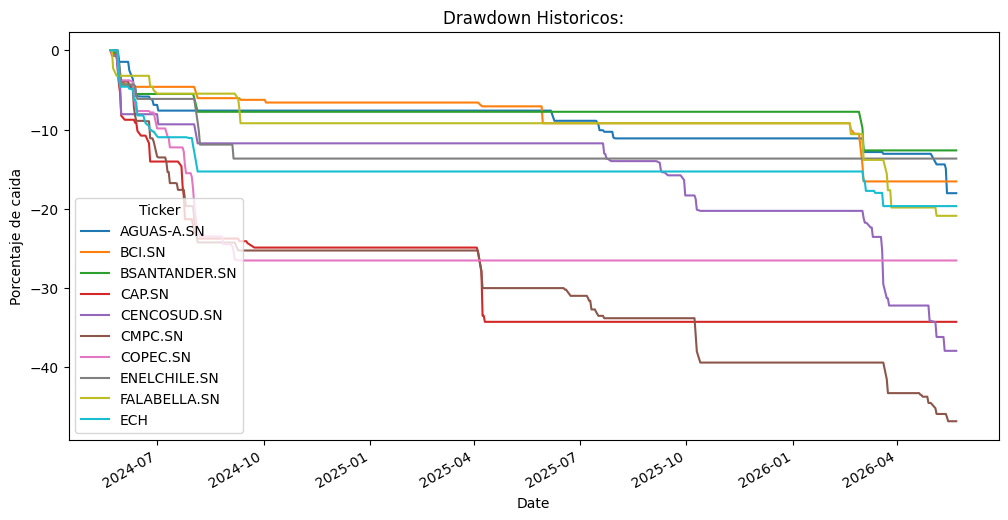

In [42]:
drawdown = ((precios_cierre - precios_cierre.cummax())/precios_cierre.cummax()) * 100
drawrecto = drawdown.cummin()
fig, dw = plt.subplots(figsize=(12,6))
dw.set_title("Drawdown Historicos:")
dw.set_ylabel("Porcentaje de caida")
dw.set_xlabel("Fecha")
drawrecto.plot(ax=dw)

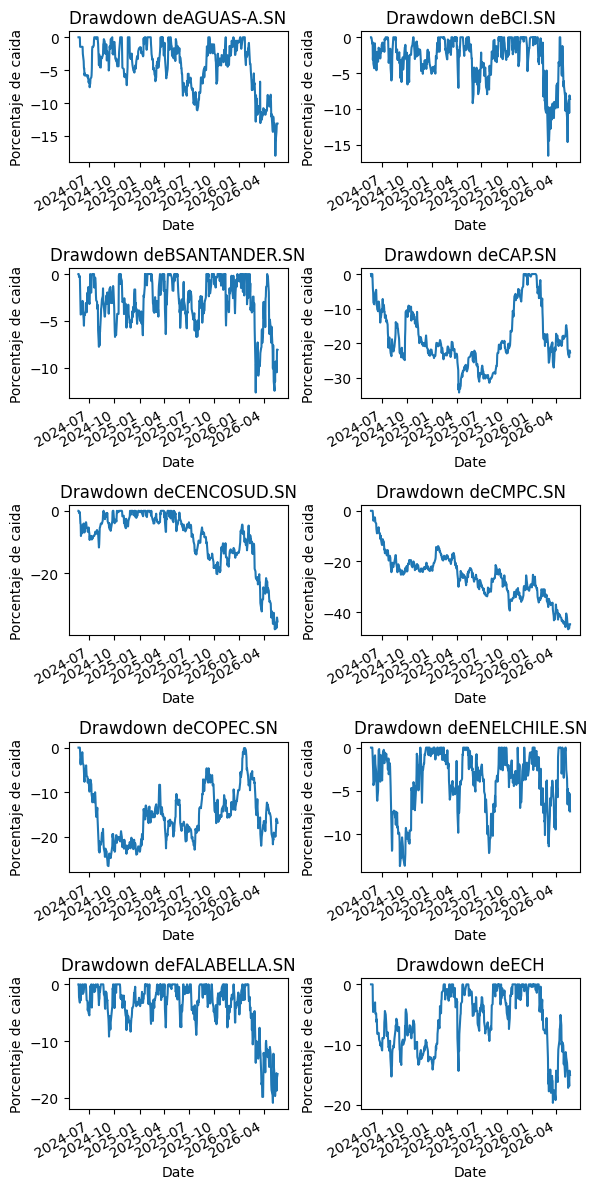

In [43]:
x = 0
y = 0

fig, dwo = plt.subplots(5, 2, figsize = (6, 12))
for i in retorno.columns:
    dwo[x][y].set_title("Drawdown de" + i)
    dwo[x][y].set_ylabel("Porcentaje de caida")
    dwo[x][y].set_xlabel("Fecha")
    drawdown[i].plot(ax = dwo[x][y])

    if y == 1:
        y = 0
        x += 1
    else:
        y += 1
plt.tight_layout(h_pad=1)

In [44]:
pd.DataFrame({"MDD [%]": drawdown.min()})

,MDD [%]
Ticker,
AGUAS-A.SN,-18.023628
BCI.SN,-16.540102
BSANTANDER.SN,-12.625622
CAP.SN,-34.253898
CENCOSUD.SN,-37.911853
CMPC.SN,-46.794581
COPEC.SN,-26.513886
ENELCHILE.SN,-13.657033
FALABELLA.SN,-20.877682


In [45]:
dataframe_pesos = pd.read_csv("pesos_nb02.csv", index_col = 0)
dataframe_pesos

,Máximo Sharpe,Mínima Varianza,Pesos iguales
AGUAS-A.SN,9.938908e-02,0.336988,0.111111
BCI.SN,4.026943e-01,0.031556,0.111111
BSANTANDER.SN,1.622860e-01,0.163528,0.111111
CAP.SN,3.702550e-17,0.151367,0.111111
CENCOSUD.SN,0.000000e+00,0.079774,0.111111
CMPC.SN,0.000000e+00,0.000000,0.111111
COPEC.SN,5.182486e-17,0.079017,0.111111
ENELCHILE.SN,9.960834e-02,0.155980,0.111111
FALABELLA.SN,2.360223e-01,0.001790,0.111111


In [53]:
retornos_max_shr = retorno[dataframe_pesos.index] @ dataframe_pesos["Máximo Sharpe"]
retornos_min_var = retorno[dataframe_pesos.index] @ dataframe_pesos["Mínima Varianza"]
retornos_pes_ig = retorno[dataframe_pesos.index] @ dataframe_pesos["Pesos iguales"]

retornos_shr_95 = retornos_max_shr[retornos_max_shr <  retornos_max_shr.quantile(0.05)] * 100
retornos_min_var_95 = retornos_min_var[retornos_min_var <  retornos_min_var.quantile(0.05)] * 100
retornos_ig_95 = retornos_pes_ig[retornos_pes_ig <  retornos_pes_ig.quantile(0.05)] * 100

retornos_shr_99 = retornos_max_shr[retornos_max_shr <  retornos_max_shr.quantile(0.01)] * 100
retornos_min_var_99 = retornos_min_var[retornos_min_var <  retornos_min_var.quantile(0.01)] * 100
retornos_ig_99 = retornos_pes_ig[retornos_pes_ig <  retornos_pes_ig.quantile(0.01)] * 100

capital_pesos = precios_cierre[dataframe_pesos.index] @ dataframe_pesos

drawdown_pesos = ((capital_pesos - capital_pesos.cummax())/capital_pesos.cummax()) * 100

    


pd.DataFrame({"Var 95[%]": [retornos_max_shr.quantile(0.05) * 100, retornos_min_var.quantile(0.05) * 100, retornos_pes_ig.quantile(0.05) * 100, retorno["ECH"].quantile(0.05) * 100],
              "CVar 95[%]": [retornos_shr_95.mean(), retornos_min_var_95.mean(), retornos_ig_95.mean(), retornos_95["ECH"].mean()],
              "VaR 99[%]": [retornos_max_shr.quantile(0.01) * 100, retornos_min_var.quantile(0.01) * 100, retornos_pes_ig.quantile(0.01) * 100, retorno["ECH"].quantile(0.01) * 100],
              "CVar 99[%]": [retornos_shr_99.mean(), retornos_min_var_99.mean(), retornos_ig_99.mean(), retornos_99["ECH"].mean()],
              "MDD[%]": [drawdown_pesos["Máximo Sharpe"].min(), drawdown_pesos["Mínima Varianza"].min(), drawdown_pesos["Pesos iguales"].min(), drawdown["ECH"].min()]}, 
              index= ["Máximo Sharpe", "Mínima Varianza", "Pesos iguales", "ECH"])

,Var 95[%],CVar 95[%],VaR 99[%],CVar 99[%],MDD[%]
Máximo Sharpe,-1.738663,-2.295133,-2.541832,-3.247139,-16.255943
Mínima Varianza,-1.356522,-1.974172,-2.584534,-3.090571,-16.782836
Pesos iguales,-1.546863,-2.065065,-2.562025,-3.145141,-15.529133
ECH,-2.358851,-3.385080,-3.952874,-4.751144,-19.653785
